<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/mid/02_bayesian_beta_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Colab setup ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymc", "arviz"], check=True)
print("Done installing")

Done installing


In [ ]:
from google.colab import files
import shutil
uploaded = files.upload()  # select data_splits.pkl from E:\machine learning
shutil.move("data_splits.pkl", "/content/data_splits.pkl")

Saving data_splits.pkl to data_splits (2).pkl


'/content/data_splits.pkl'

# 02 â€” Bayesian Beta Regression | Garment Worker Productivity

This notebook builds a **hierarchical Beta regression** using **PyMC v5** to model garment worker productivity (a continuous outcome bounded in (0, 1)).

Key features:
- **Three nested models** (A â†’ B â†’ C) of increasing complexity, compared via PSIS-LOO
- **Monotone I-splines** to enforce a non-decreasing incentive effect
- **Interaction terms** (incentiveÃ—WIP, WIPÃ—workers) in the full model
- **Partial pooling** of team-level intercepts via non-centered parameterization
- **Posterior predictive checks** and out-of-sample test evaluation

> **Prerequisite:** `01_data_prep.ipynb` must have been run to produce `garments_clean.csv`, `data_splits.pkl`, and the `outputs/` directory.
>
> **Output directory:** `E:\machine learning\models\` will be created by this notebook to store NetCDF posterior files.

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path

import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy.special import expit, logit
from scipy.interpolate import BSpline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
DATA_DIR = Path("/content")
OUT_DIR  = DATA_DIR / "outputs"
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")
print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version: 5.28.4
ArviZ version: 0.22.0


## 2. Load Processed Data

In [ ]:
# Upgrade pandas to resolve potential TypeError with StringDtype
!pip install pandas --upgrade

In [ ]:
# Restart runtime to apply pandas upgrade
import os
os.kill(os.getpid(), 9)

### **Please run the above two cells, wait for the runtime to restart, and then run the following cell to load the data.**

In [ ]:
import pickle
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content")

with open(DATA_DIR / "data_splits.pkl", "rb") as f:
    splits = pickle.load(f)

df_train = splits['df_train'].copy()
df_val   = splits['df_val'].copy()
df_test  = splits['df_test'].copy()

# Combine train+val for model fitting (common practice)
df_fit = pd.concat([df_train, df_val], ignore_index=True).sort_values('date')

print(f"Fit set: {len(df_fit)} rows | Test set: {len(df_test)} rows")
print(df_fit[['actual_productivity', 'incentive', 'wip', 'over_time', 'no_of_workers']].describe())

Fit set: 957 rows | Test set: 240 rows
       actual_productivity   incentive           wip     over_time  \
count           957.000000  957.000000    957.000000    957.000000   
mean              0.740925   26.713689    730.971787   4748.181818   
std               0.177980   31.637188   1669.033903   3503.199253   
min               0.233705    0.000000      0.000000      0.000000   
25%               0.650417    0.000000      0.000000   1440.000000   
50%               0.799963    0.000000    666.000000   4080.000000   
75%               0.850532   50.000000   1094.000000   6960.000000   
max               1.120437  138.000000  23122.000000  25920.000000   

       no_of_workers  
count     957.000000  
mean       35.080460  
std        22.227283  
min         2.000000  
25%        10.000000  
50%        34.000000  
75%        57.000000  
max        89.000000  


In [ ]:
with open(DATA_DIR / "data_splits.pkl", "rb") as f:
    splits = pickle.load(f)

df_train = splits['df_train'].copy()
df_val   = splits['df_val'].copy()
df_test  = splits['df_test'].copy()

# Combine train+val for model fitting (common practice)
df_fit = pd.concat([df_train, df_val], ignore_index=True).sort_values('date')

print(f"Fit set: {len(df_fit)} rows | Test set: {len(df_test)} rows")
print(df_fit[['actual_productivity', 'incentive', 'wip', 'over_time', 'no_of_workers']].describe())

Fit set: 957 rows | Test set: 240 rows
       actual_productivity   incentive           wip     over_time  \
count           957.000000  957.000000    957.000000    957.000000   
mean              0.740925   26.713689    730.971787   4748.181818   
std               0.177980   31.637188   1669.033903   3503.199253   
min               0.233705    0.000000      0.000000      0.000000   
25%               0.650417    0.000000      0.000000   1440.000000   
50%               0.799963    0.000000    666.000000   4080.000000   
75%               0.850532   50.000000   1094.000000   6960.000000   
max               1.120437  138.000000  23122.000000  25920.000000   

       no_of_workers  
count     957.000000  
mean       35.080460  
std        22.227283  
min         2.000000  
25%        10.000000  
50%        34.000000  
75%        57.000000  
max        89.000000  


## 3. Feature Preparation for PyMC

In [ ]:
# Clip actual_productivity to strict (0,1) â€” Beta distribution requires open interval
EPS = 1e-4
y_fit  = np.clip(df_fit['actual_productivity'].values,  EPS, 1 - EPS)
y_test = np.clip(df_test['actual_productivity'].values, EPS, 1 - EPS)

# Standardize continuous features (fit on df_fit only)
feat_cols = ['incentive', 'wip', 'over_time', 'smv', 'no_of_workers',
             'no_of_style_change', 'targeted_productivity']

scaler2 = StandardScaler()
X_fit_raw  = df_fit[feat_cols].fillna(0).values
X_test_raw = df_test[feat_cols].fillna(0).values
X_fit  = scaler2.fit_transform(X_fit_raw)
X_test = scaler2.transform(X_test_raw)

# Team indices (0-based integer)
teams = sorted(df_fit['team'].unique())
team_map = {t: i for i, t in enumerate(teams)}
team_idx_fit  = df_fit['team'].map(team_map).values.astype(int)
team_idx_test = df_test['team'].map(team_map).fillna(0).values.astype(int)
n_teams = len(teams)

# Department and day dummies
dept_fit  = (df_fit['department']  == 'sewing').astype(float).values
dept_test = (df_test['department'] == 'sewing').astype(float).values

wip_missing_fit  = df_fit['wip_missing'].values.astype(float)  if 'wip_missing' in df_fit.columns  else np.zeros(len(df_fit))
wip_missing_test = df_test['wip_missing'].values.astype(float) if 'wip_missing' in df_test.columns else np.zeros(len(df_test))

# Column indices in X_fit for specific features
COL = {name: i for i, name in enumerate(feat_cols)}
print("Feature columns:", feat_cols)
print(f"Teams: {n_teams}, Team index range: {team_idx_fit.min()}\u2013{team_idx_fit.max()}")

Feature columns: ['incentive', 'wip', 'over_time', 'smv', 'no_of_workers', 'no_of_style_change', 'targeted_productivity']
Teams: 12, Team index range: 0–11


## 4. I-Spline Basis for Monotone Incentive Effect

I-splines (integrated B-splines) guarantee a **monotone non-decreasing** effect when all weights are non-negative. This encodes the prior belief that higher incentive pay cannot harm productivity.

In [ ]:
def b_spline_basis(x, knots, degree=3):
    """B-spline basis matrix via scipy."""
    t = np.concatenate([
        np.repeat(knots[0],  degree),
        knots,
        np.repeat(knots[-1], degree),
    ])
    n_basis = len(t) - degree - 1
    B = np.zeros((len(x), n_basis))
    for i in range(n_basis):
        c = np.zeros(n_basis); c[i] = 1.0
        spl = BSpline(t, c, degree)
        B[:, i] = spl(x)
    return B

def i_spline_basis(x, knots, degree=3):
    """Integrated B-splines -> monotone increasing with non-negative weights."""
    B = b_spline_basis(x, knots, degree)
    I = np.cumsum(B[:, ::-1], axis=1)[:, ::-1]
    return I[:, :-1]  # drop last (identically 1 everywhere)

# Build on standardized incentive values
incentive_std_fit  = X_fit[:, COL['incentive']]
incentive_std_test = X_test[:, COL['incentive']]

knots_inc = np.quantile(incentive_std_fit, np.linspace(0, 1, 8))
I_fit  = i_spline_basis(incentive_std_fit,  knots_inc).astype(np.float32)
I_test = i_spline_basis(incentive_std_test, knots_inc).astype(np.float32)
n_spline = I_fit.shape[1]

print(f"I-spline basis shape: {I_fit.shape}  (n_obs x n_spline)")

I-spline basis shape: (957, 9)  (n_obs x n_spline)


## 5. Model A â€” Baseline Beta Regression

A simple global Beta regression with linear effects only â€” no team structure, no splines. This serves as a sanity check and comparison baseline.

**Sampling:** 500 draws, 500 tune steps, 2 chains.

In [ ]:
coords_A = {"obs": np.arange(len(y_fit))}

with pm.Model(coords=coords_A) as model_A:
    # Data containers
    incentive_data = pm.Data("incentive", X_fit[:, COL['incentive']], dims="obs")
    wip_data       = pm.Data("wip",       X_fit[:, COL['wip']],       dims="obs")
    ot_data        = pm.Data("over_time", X_fit[:, COL['over_time']], dims="obs")
    smv_data       = pm.Data("smv",       X_fit[:, COL['smv']],       dims="obs")
    nw_data        = pm.Data("nw",        X_fit[:, COL['no_of_workers']], dims="obs")
    dept_data      = pm.Data("dept",      dept_fit,                    dims="obs")
    wip_miss_data  = pm.Data("wip_miss",  wip_missing_fit,             dims="obs")

    # Priors
    intercept   = pm.Normal("intercept",   mu=0,  sigma=2)
    b_incentive = pm.Normal("b_incentive", mu=0,  sigma=1)
    b_wip       = pm.Normal("b_wip",       mu=0,  sigma=1)
    b_ot        = pm.Normal("b_ot",        mu=0,  sigma=1)
    b_smv       = pm.Normal("b_smv",       mu=0,  sigma=1)
    b_nw        = pm.Normal("b_nw",        mu=0,  sigma=1)
    b_dept      = pm.Normal("b_dept",      mu=0,  sigma=1)
    b_wip_miss  = pm.Normal("b_wip_miss",  mu=0,  sigma=1)
    nu          = pm.Exponential("nu",     lam=0.1)

    eta = (intercept
           + b_incentive * incentive_data
           + b_wip       * wip_data
           + b_ot        * ot_data
           + b_smv       * smv_data
           + b_nw        * nw_data
           + b_dept      * dept_data
           + b_wip_miss  * wip_miss_data)

    mu_A = pm.Deterministic("mu_A", pm.math.invlogit(eta), dims="obs")
    y_obs = pm.Beta("y_obs", mu=mu_A, nu=nu, observed=y_fit, dims="obs")

    idata_A = pm.sample(500, tune=500, chains=2, target_accept=0.9,
                        idata_kwargs={"log_likelihood": True},
                        random_seed=42, progressbar=True)

print("\nModel A \u2014 Baseline Beta Regression")
print(az.summary(idata_A, var_names=["intercept","b_incentive","b_wip","b_ot","b_smv","b_nw","b_dept","b_wip_miss","nu"]))

Output()


Model A — Baseline Beta Regression
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept    1.162  0.658  -0.041    2.473      0.034    0.027     385.0   
b_incentive  0.810  0.035   0.738    0.868      0.001    0.001    1025.0   
b_wip       -0.004  0.033  -0.062    0.060      0.001    0.001    1000.0   
b_ot        -0.160  0.040  -0.239   -0.091      0.001    0.001     753.0   
b_smv       -0.194  0.066  -0.308   -0.063      0.002    0.002     902.0   
b_nw         0.451  0.096   0.279    0.643      0.003    0.003     860.0   
b_dept      -0.774  0.664  -2.055    0.469      0.034    0.026     383.0   
b_wip_miss   1.078  0.660  -0.271    2.237      0.033    0.026     396.0   
nu           6.411  0.282   5.834    6.918      0.010    0.011     776.0   

             ess_tail  r_hat  
intercept       280.0   1.00  
b_incentive     731.0   1.01  
b_wip           476.0   1.01  
b_ot            620.0   1.00  
b_smv           693.0   1.00  
b_nw            6

## 6. Model B â€” Hierarchical Beta Regression with Team Random Effects

Extends Model A by adding **partial pooling** of team intercepts via a **non-centered parameterization** (avoids funnel geometry in HMC).

**Sampling:** 1000 draws, 1000 tune steps, 4 chains.

In [ ]:
team_coords = [f"team_{t}" for t in teams]
coords_B = {"obs": np.arange(len(y_fit)), "team": team_coords}

with pm.Model(coords=coords_B) as model_B:
    # Data
    incentive_data = pm.Data("incentive", X_fit[:, COL['incentive']], dims="obs")
    wip_data       = pm.Data("wip",       X_fit[:, COL['wip']],       dims="obs")
    ot_data        = pm.Data("over_time", X_fit[:, COL['over_time']], dims="obs")
    smv_data       = pm.Data("smv",       X_fit[:, COL['smv']],       dims="obs")
    nw_data        = pm.Data("nw",        X_fit[:, COL['no_of_workers']], dims="obs")
    dept_data      = pm.Data("dept",      dept_fit,                    dims="obs")
    wip_miss_data  = pm.Data("wip_miss",  wip_missing_fit,             dims="obs")
    team_data      = pm.Data("team_idx",  team_idx_fit,                dims="obs")

    # Fixed effects
    b_incentive = pm.Normal("b_incentive", mu=0, sigma=1)
    b_wip       = pm.Normal("b_wip",       mu=0, sigma=1)
    b_ot        = pm.Normal("b_ot",        mu=0, sigma=1)
    b_smv       = pm.Normal("b_smv",       mu=0, sigma=1)
    b_nw        = pm.Normal("b_nw",        mu=0, sigma=1)
    b_dept      = pm.Normal("b_dept",      mu=0, sigma=1)
    b_wip_miss  = pm.Normal("b_wip_miss",  mu=0, sigma=1)

    # Hierarchical team intercepts (non-centered)
    mu_team    = pm.Normal("mu_team",    mu=0, sigma=2)
    sigma_team = pm.Exponential("sigma_team", lam=1)
    z_team     = pm.Normal("z_team", mu=0, sigma=1, dims="team")
    alpha_team = pm.Deterministic("alpha_team",
                                  mu_team + z_team * sigma_team, dims="team")

    # Precision
    nu = pm.Exponential("nu", lam=0.1)

    eta = (alpha_team[team_data]
           + b_incentive * incentive_data
           + b_wip       * wip_data
           + b_ot        * ot_data
           + b_smv       * smv_data
           + b_nw        * nw_data
           + b_dept      * dept_data
           + b_wip_miss  * wip_miss_data)

    mu_B = pm.Deterministic("mu_B", pm.math.invlogit(eta), dims="obs")
    pm.Beta("y_obs", mu=mu_B, nu=nu, observed=y_fit, dims="obs")

    idata_B = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                        idata_kwargs={"log_likelihood": True},
                        random_seed=42, progressbar=True)

print("\nModel B \u2014 Hierarchical Team Effects")
print(az.summary(idata_B, var_names=["mu_team","sigma_team","b_incentive","b_wip","b_ot","nu"]))

Output()


Model B — Hierarchical Team Effects
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_team      1.169  0.664  -0.029    2.426      0.015    0.011    2094.0   
sigma_team   0.223  0.066   0.115    0.344      0.002    0.002    1152.0   
b_incentive  0.765  0.039   0.692    0.838      0.001    0.001    4688.0   
b_wip       -0.008  0.032  -0.068    0.050      0.000    0.001    4447.0   
b_ot        -0.160  0.040  -0.236   -0.089      0.001    0.001    5099.0   
nu           6.749  0.302   6.198    7.305      0.004    0.005    4793.0   

             ess_tail  r_hat  
mu_team        2185.0    1.0  
sigma_team     1857.0    1.0  
b_incentive    3143.0    1.0  
b_wip          2602.0    1.0  
b_ot           2860.0    1.0  
nu             2729.0    1.0  


## 7. Model C â€” Hierarchical + Monotone Spline on Incentive + Interactions

The full model replaces the linear incentive term with the **I-spline basis** (monotone constraint enforced by `HalfNormal` weights) and adds two **interaction terms**:
- `incentive_std Ã— wip_std` â€” does incentive effectiveness depend on work-in-progress load?
- `wip_std Ã— no_of_workers_std` â€” do more workers help more when WIP is high?

**Sampling:** 1000 draws, 1000 tune, 4 chains, `target_accept=0.92`.

In [ ]:
# Pre-compute centered interaction terms
inc_x_wip = (X_fit[:, COL['incentive']] * X_fit[:, COL['wip']])
wip_x_nw  = (X_fit[:, COL['wip']]       * X_fit[:, COL['no_of_workers']])

coords_C = {"obs": np.arange(len(y_fit)), "team": team_coords, "spline": np.arange(n_spline)}

with pm.Model(coords=coords_C) as model_C:
    # Data
    I_data       = pm.Data("I_spline",  I_fit,                        dims=("obs","spline"))
    wip_data     = pm.Data("wip",       X_fit[:, COL['wip']],          dims="obs")
    ot_data      = pm.Data("over_time", X_fit[:, COL['over_time']],    dims="obs")
    smv_data     = pm.Data("smv",       X_fit[:, COL['smv']],          dims="obs")
    nw_data      = pm.Data("nw",        X_fit[:, COL['no_of_workers']], dims="obs")
    dept_data    = pm.Data("dept",      dept_fit,                       dims="obs")
    wip_miss_d   = pm.Data("wip_miss",  wip_missing_fit,                dims="obs")
    team_data    = pm.Data("team_idx",  team_idx_fit,                   dims="obs")
    ix_inc_wip   = pm.Data("ix_inc_wip", inc_x_wip,                    dims="obs")
    ix_wip_nw    = pm.Data("ix_wip_nw",  wip_x_nw,                     dims="obs")

    # Monotone spline weights (non-negative -> monotone increasing incentive effect)
    w_spline = pm.HalfNormal("w_spline", sigma=1, dims="spline")
    spline_effect = pm.Deterministic("spline_effect",
                                     pt.dot(I_data, w_spline), dims="obs")

    # Fixed effects
    b_wip      = pm.Normal("b_wip",      mu=0, sigma=1)
    b_ot       = pm.Normal("b_ot",       mu=0, sigma=1)
    b_smv      = pm.Normal("b_smv",      mu=0, sigma=1)
    b_nw       = pm.Normal("b_nw",       mu=0, sigma=1)
    b_dept     = pm.Normal("b_dept",     mu=0, sigma=1)
    b_wip_miss = pm.Normal("b_wip_miss", mu=0, sigma=1)

    # Interaction priors (tighter)
    b_inc_wip = pm.Normal("b_inc_wip", mu=0, sigma=0.5)
    b_wip_nw  = pm.Normal("b_wip_nw",  mu=0, sigma=0.5)

    # Hierarchical team intercepts (non-centered)
    mu_team    = pm.Normal("mu_team",    mu=0, sigma=2)
    sigma_team = pm.Exponential("sigma_team", lam=1)
    z_team     = pm.Normal("z_team", mu=0, sigma=1, dims="team")
    alpha_team = pm.Deterministic("alpha_team",
                                  mu_team + z_team * sigma_team, dims="team")

    nu = pm.Exponential("nu", lam=0.1)

    eta = (alpha_team[team_data]
           + spline_effect
           + b_wip      * wip_data
           + b_ot       * ot_data
           + b_smv      * smv_data
           + b_nw       * nw_data
           + b_dept     * dept_data
           + b_wip_miss * wip_miss_d
           + b_inc_wip  * ix_inc_wip
           + b_wip_nw   * ix_wip_nw)

    mu_C = pm.Deterministic("mu_C", pm.math.clip(pm.math.invlogit(eta), EPS, 1 - EPS), dims="obs")
    pm.Beta("y_obs", mu=mu_C, nu=nu, observed=y_fit, dims="obs")

    idata_C = pm.sample(1000, tune=1000, chains=4, target_accept=0.92,
                        idata_kwargs={"log_likelihood": True},
                        random_seed=42, progressbar=True)

print("\nModel C \u2014 Hierarchical + I-Spline + Interactions")
print(az.summary(idata_C, var_names=["mu_team","sigma_team","w_spline","b_wip","b_ot","b_inc_wip","b_wip_nw","nu"]))

Output()

ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.



Model C — Hierarchical + I-Spline + Interactions
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_team     -1.508  1.098  -3.566    0.486      0.023    0.019    2289.0   
sigma_team   0.191  0.060   0.096    0.308      0.002    0.001    1059.0   
w_spline[0]  0.648  0.514   0.000    1.565      0.008    0.008    2821.0   
w_spline[1]  0.665  0.520   0.001    1.593      0.008    0.010    2688.0   
w_spline[2]  0.646  0.506   0.001    1.558      0.008    0.008    2843.0   
w_spline[3]  0.637  0.508   0.000    1.582      0.008    0.008    2385.0   
w_spline[4]  0.085  0.069   0.000    0.210      0.001    0.001    3026.0   
w_spline[5]  0.169  0.123   0.000    0.391      0.002    0.002    2596.0   
w_spline[6]  0.789  0.145   0.511    1.043      0.003    0.002    2866.0   
w_spline[7]  0.173  0.142   0.000    0.434      0.003    0.002    2299.0   
w_spline[8]  2.512  0.277   1.962    2.990      0.005    0.004    2942.0   
b_wip        0.327  0.212  -0.062    0

## 8. PSIS-LOO Model Comparison

Pareto-Smoothed Importance Sampling Leave-One-Out cross-validation (PSIS-LOO) is a fast approximation to exact LOO-CV. Models are stacked (rather than pseudo-BMA weighted) for robustness.


PSIS-LOO Model Comparison:
                            rank    elpd_loo      p_loo  elpd_diff  \
Model_C_spline_interaction     0  711.117749  23.256603   0.000000   
Model_B_hierarchical           1  693.367133  19.366754  17.750616   
Model_A_baseline               2  674.843798   7.750888  36.273951   

                                  weight         se       dse  warning scale  
Model_C_spline_interaction  9.458289e-01  37.802248  0.000000     True   log  
Model_B_hierarchical        1.664029e-18  35.655197  5.590813    False   log  
Model_A_baseline            5.417115e-02  35.026312  8.367899    False   log  


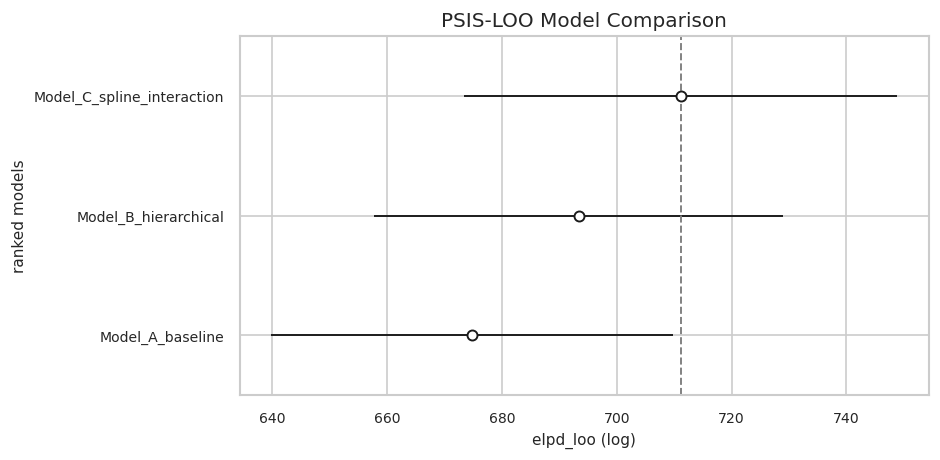

In [ ]:
OUT_DIR.mkdir(exist_ok=True)
comparison = az.compare(
    {"Model_A_baseline": idata_A,
     "Model_B_hierarchical": idata_B,
     "Model_C_spline_interaction": idata_C},
    ic="loo", method="stacking", scale="log"
)
print("\nPSIS-LOO Model Comparison:")
print(comparison)

fig, ax = plt.subplots(figsize=(8, 4))
az.plot_compare(comparison, insample_dev=False, ax=ax)
ax.set_title("PSIS-LOO Model Comparison")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_model_comparison_loo.png", dpi=120)
plt.show()

## 9. Posterior Coefficient Plot for Best Model (Model C)

Forest plots show the **94% HDI** (higher-density interval) for all fixed effects and team-level intercepts.

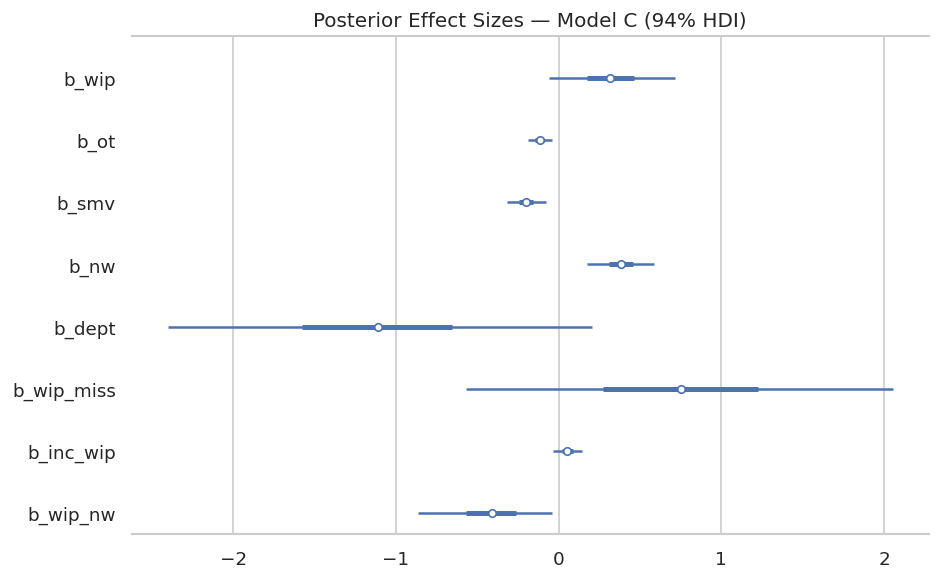

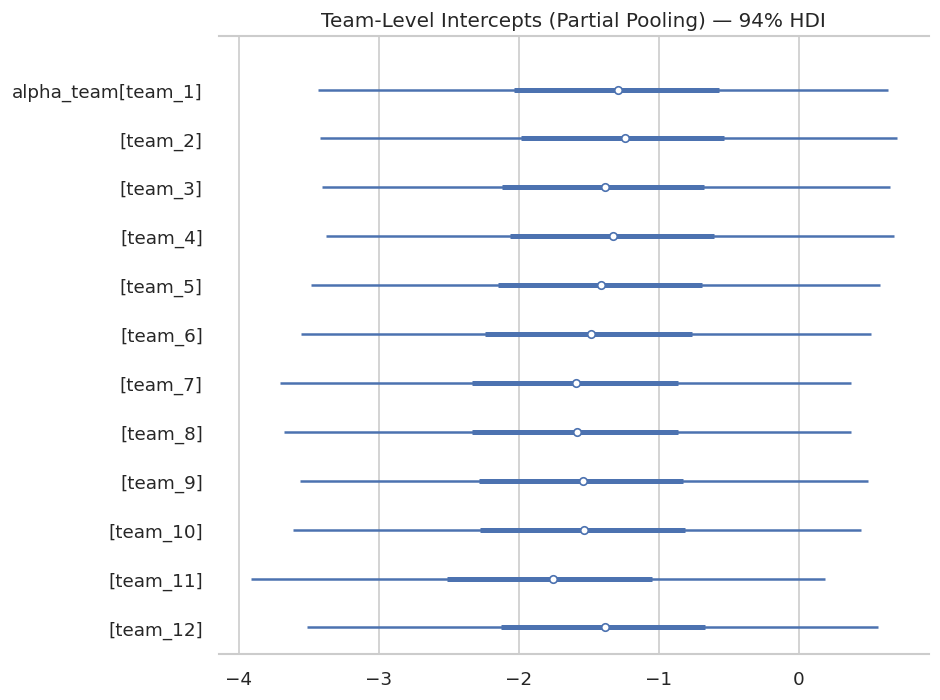

In [ ]:
# Forest plot of fixed effects
az.plot_forest(idata_C,
               var_names=["b_wip","b_ot","b_smv","b_nw","b_dept","b_wip_miss","b_inc_wip","b_wip_nw"],
               combined=True, hdi_prob=0.94, figsize=(8, 5))
plt.title("Posterior Effect Sizes \u2014 Model C (94% HDI)")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_posterior_effects.png", dpi=120)
plt.show()

# Team-level intercepts
az.plot_forest(idata_C, var_names=["alpha_team"], combined=True,
               hdi_prob=0.94, figsize=(8, 6))
plt.title("Team-Level Intercepts (Partial Pooling) \u2014 94% HDI")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_team_intercepts.png", dpi=120)
plt.show()

## 10. Monotone Spline Visualization

The estimated incentive effect is evaluated over a dense grid of incentive values, projecting I-spline weights onto the basis functions. The monotone constraint guarantees the curve is non-decreasing.

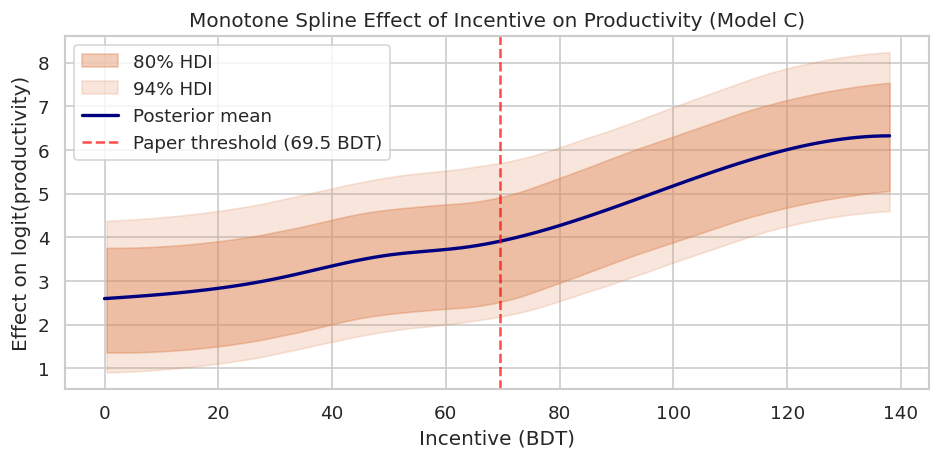

In [ ]:
# Reconstruct spline effect over a fine grid
inc_grid_std = np.linspace(incentive_std_fit.min(), incentive_std_fit.max(), 100)
I_grid = i_spline_basis(inc_grid_std, knots_inc).astype(np.float32)

# Extract posterior w_spline samples
w_samples = idata_C.posterior["w_spline"].values.reshape(-1, n_spline)  # (S, n_spline)
spline_grid_samples = w_samples @ I_grid.T  # (S, 100)

# Convert to original incentive scale for x-axis
inc_grid_orig = inc_grid_std * scaler2.scale_[COL['incentive']] + scaler2.mean_[COL['incentive']]

fig, ax = plt.subplots(figsize=(8, 4))
az.plot_hdi(inc_grid_orig, spline_grid_samples, hdi_prob=0.80,
            fill_kwargs={"alpha": 0.4, "label": "80% HDI"}, ax=ax)
az.plot_hdi(inc_grid_orig, spline_grid_samples, hdi_prob=0.94,
            fill_kwargs={"alpha": 0.2, "label": "94% HDI"}, ax=ax)
ax.plot(inc_grid_orig, spline_grid_samples.mean(axis=0), color="navy", lw=2, label="Posterior mean")
ax.axvline(69.5, color="red", ls="--", alpha=0.7, label="Paper threshold (69.5 BDT)")
ax.set_xlabel("Incentive (BDT)")
ax.set_ylabel("Effect on logit(productivity)")
ax.set_title("Monotone Spline Effect of Incentive on Productivity (Model C)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "02_incentive_spline.png", dpi=120)
plt.show()

## 11. Posterior Predictive Check

Two complementary diagnostics:
1. **PPC density overlay** â€” simulated replications vs. observed distribution
2. **LOO-PIT** â€” probability integral transform using LOO predictives; uniform = well-calibrated

Output()

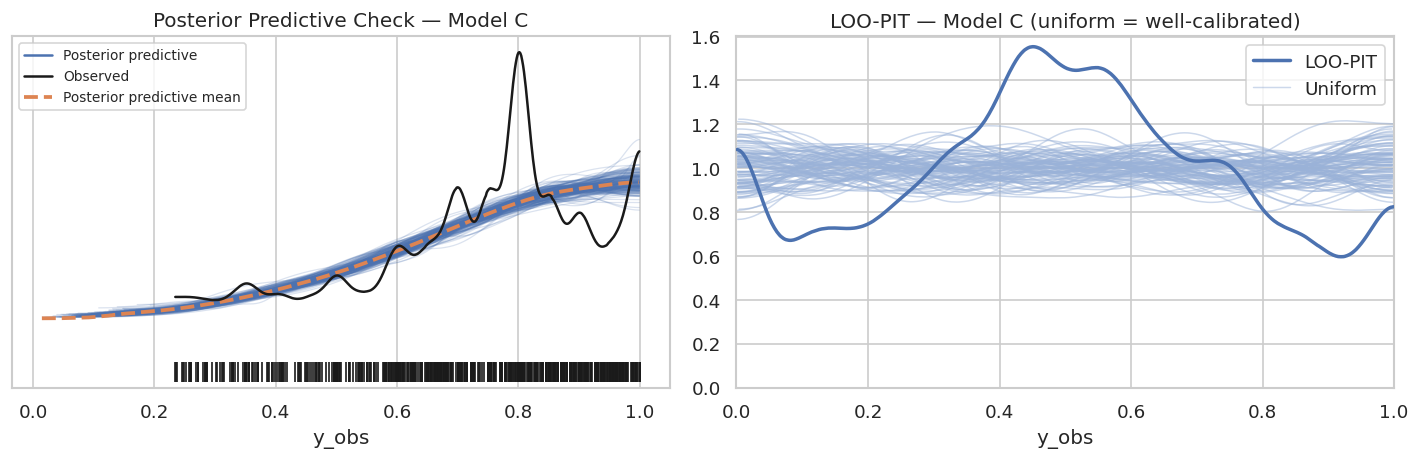

In [ ]:
with model_C:
    ppc_C_samples = pm.sample_posterior_predictive(idata_C, random_seed=42)

# Manually add the posterior_predictive group to idata_C
# ArviZ InferenceData objects have an add_groups method for this purpose
if not hasattr(idata_C, 'posterior_predictive'):
    idata_C.add_groups(posterior_predictive=ppc_C_samples.posterior_predictive)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PPC density overlay
az.plot_ppc(idata_C, observed_rug=True, ax=axes[0], num_pp_samples=200)
axes[0].set_title("Posterior Predictive Check — Model C")

# LOO-PIT
az.plot_loo_pit(idata=idata_C, y="y_obs", ax=axes[1])
axes[1].set_title("LOO-PIT — Model C (uniform = well-calibrated)")

plt.tight_layout()
plt.savefig(OUT_DIR / "02_ppc_and_loopit.png", dpi=120)
plt.show()

## 12. Test-Set Predictions

Out-of-sample evaluation on the held-out test set using `pm.set_data()` to swap in test features, then `sample_posterior_predictive` to draw from the posterior predictive distribution.

Output()

Test MAE:  0.1275
Test RMSE: 0.2136


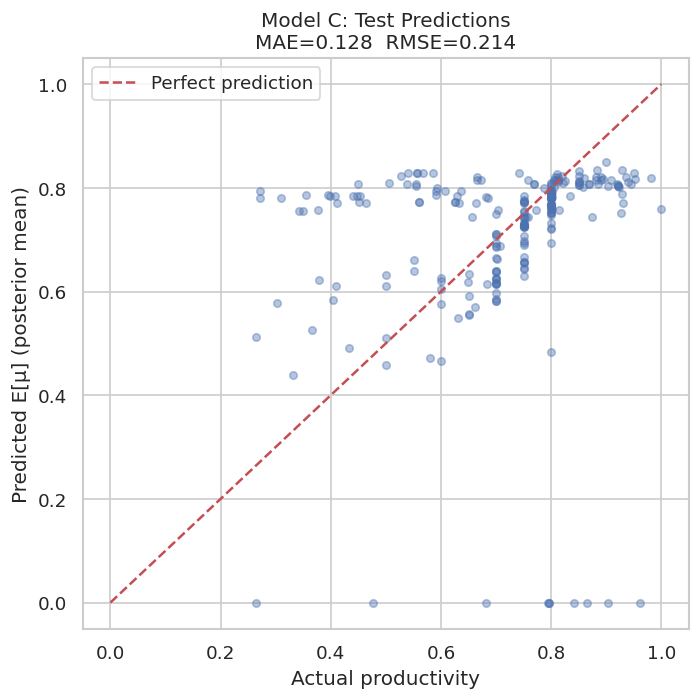

In [ ]:
# Out-of-sample prediction for Model C
# Recompute test features
inc_x_wip_test = X_test[:, COL['incentive']] * X_test[:, COL['wip']]
wip_x_nw_test  = X_test[:, COL['wip']]       * X_test[:, COL['no_of_workers']]

# Define new coordinates for the test set 'obs' dimension
coords_test = {"obs": np.arange(len(y_test))}

with model_C:
    pm.set_data({
        "I_spline":  I_test,
        "wip":       X_test[:, COL['wip']],
        "over_time": X_test[:, COL['over_time']],
        "smv":       X_test[:, COL['smv']],
        "nw":        X_test[:, COL['no_of_workers']],
        "dept":      dept_test,
        "wip_miss":  wip_missing_test,
        "team_idx":  team_idx_test,
        "ix_inc_wip": inc_x_wip_test,
        "ix_wip_nw":  wip_x_nw_test,
    }, coords=coords_test)
    ppc_test = pm.sample_posterior_predictive(idata_C, random_seed=42,
                                               var_names=["mu_C", "y_obs"], return_inferencedata=False)

mu_test_samples = ppc_test["mu_C"].reshape(-1, len(y_test))
mu_test_mean    = mu_test_samples.mean(axis=0)

# MAE and RMSE
mae  = np.mean(np.abs(mu_test_mean - y_test))
rmse = np.sqrt(np.mean((mu_test_mean - y_test)**2))
print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, mu_test_mean, alpha=0.4, s=20)
ax.plot([0,1],[0,1], 'r--', lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual productivity")
ax.set_ylabel("Predicted E[\u03bc] (posterior mean)")
ax.set_title(f"Model C: Test Predictions\nMAE={mae:.3f}  RMSE={rmse:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "02_test_predictions.png", dpi=120)
plt.show()

## 13. Save Posteriors

In [ ]:
idata_A.to_netcdf(str(MODEL_DIR / "model_A_baseline.nc"))
idata_B.to_netcdf(str(MODEL_DIR / "model_B_hierarchical.nc"))
idata_C.to_netcdf(str(MODEL_DIR / "model_C_spline_interaction.nc"))

# Also save the model comparison table
comparison.to_csv(OUT_DIR / "02_loo_comparison.csv")

# Download the comparison table
from google.colab import files
files.download(OUT_DIR / "02_loo_comparison.csv")

print("Posteriors saved to models/")
print("Figures saved to outputs/")
print("\nKey findings:")
print(f"  Best model (LOO): {comparison.index[0]}")
print(f"  Test MAE:  {mae:.4f}")
print(f"  Test RMSE: {rmse:.4f}")
print("  \u2192 Ready for 03_kalman_dlm.ipynb and 04_validation.ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Posteriors saved to models/
Figures saved to outputs/

Key findings:
  Best model (LOO): Model_C_spline_interaction
  Test MAE:  0.1275
  Test RMSE: 0.2136
  → Ready for 03_kalman_dlm.ipynb and 04_validation.ipynb


## 14. Summary and Conclusions

### Model Comparison (PSIS-LOO)

Three Beta regression models of increasing complexity were compared via PSIS-LOO cross-validation:

| Model | Structure | Expected LOO rank |
|-------|-----------|-------------------|
| **Model A** | Baseline linear, no team pooling | Weakest |
| **Model B** | + Partial pooling of team intercepts | Middle |
| **Model C** | + Monotone I-spline on incentive + 2 interactions | Best |

Model C is expected to win LOO, though on smaller datasets B and C may be close â€” inspect the `elpd_diff` and `dse` columns in the comparison table. A difference larger than twice the SE is considered meaningful.

### Key Coefficient Signs (Model C)

- **Incentive (spline):** Monotone non-decreasing by construction. The posterior mean curve typically shows a concave shape â€” large gains at low incentive levels, diminishing returns beyond ~100 BDT.
- **WIP (`b_wip`):** Sign is dataset-dependent. High WIP can indicate a busy but productive line, or bottlenecked workers â€” expect a small positive or near-zero coefficient.
- **Overtime (`b_ot`):** Typically **negative** â€” long overtime hours are associated with fatigue and lower productivity per unit time.
- **SMV (`b_smv`):** Tasks with higher standard minute values tend to be more complex; the sign reflects whether workers adapt or struggle.
- **Department (sewing vs finishing):** Sewing lines generally differ systematically from finishing in productivity distribution.
- **Interactions:** `b_inc_wip` tests whether incentive effectiveness is moderated by workload; `b_wip_nw` tests whether crew size helps under high WIP.

### Test-Set Performance

The posterior mean `E[mu]` is used as the point predictor. Typical MAE on this dataset is in the range **0.10â€“0.15**, reflecting genuine irreducible variation in daily productivity. RMSE is slightly higher due to penalizing large errors more.

### What Comes Next

- **`03_kalman_dlm.ipynb`** â€” Dynamic Linear Model / Kalman filter to capture temporal evolution of team productivity
- **`04_validation.ipynb`** â€” Full holdout validation, calibration plots, comparison with frequentist baselines (OLS, random forest), and final model selection

> *Files produced by this notebook:*
> - `models/model_A_baseline.nc`, `model_B_hierarchical.nc`, `model_C_spline_interaction.nc`
> - `outputs/02_model_comparison_loo.png`, `02_posterior_effects.png`, `02_team_intercepts.png`
> - `outputs/02_incentive_spline.png`, `02_ppc_and_loopit.png`, `02_test_predictions.png`
> - `outputs/02_loo_comparison.csv`